<a href="https://colab.research.google.com/github/NickLarsonUVA/DS3001-programming/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models - Nick Larson

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
A model is considered linear because it is linear in its parameters (the weights or coefficients). It relies on a simple additive equation where we multiply our features by these weights and add them up. Even if you transform a feature by squaring it or taking the log, the model itself remains linear because it is still just estimating a fixed weight to multiply that new feature by to predict the target.
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
To avoid the dummy variable trap, we always drop one category when one hot encoding, and that dropped category becomes the baseline value represented by the model's intercept. Therefore, the coefficient for any included dummy variable is interpreted as the expected difference in your target variable compared to that baseline dropped category, assuming all other variables are held constant.
3. Can linear regression be used for classification? Explain why, or why not.
It's usually a bad idea because linear regression is designed to predict continuous numbers and will draw a straight line that stretches infinitely. It will eventually start predicting impossible probabilities like -0.5 or 1.8. Furthermore, the line is heavily skewed by outliers, which is why we instead use Logistic Regression for classification to cleanly squish predictions between 0 and 1.
4. What are signs that your linear model is over-fitting?
The biggest sign of over-fitting is a gap in performance between your training data and your unseen testing data. This really means that the model basically memorized the training data but fails to generalize to new scenarios. If you keep adding variables and your training error drops but your testing error suddenly spikes, your model is over-fit and too complex.
5. Clearly explain multi-colinearity using the two-stage least squares technique.
Multi-collinearity happens when two features are highly correlated and explain the exact same information. Using the two-stage thought process, if we regress one twin feature against all others (Stage 1), they cancel each other out. This leaves barely any unique signal leftover to predict the actual target (Stage 2). The lack of unique signal confuses the model, leading to "mushy" and  volatile coefficients because the math doesn't know which variable to properly credit.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
You can trick a linear model into learning curves through feature engineering before you even run the regression. By manually creating a new column in your dataset that squares the original feature or takes its logarithm, the model will still apply a simple linear weight to that new column. But, the resulting relationship it maps out against the original target variable will be nonlinear.
7. What is the interpretation of the slope coefficient in a linear regression?
The slope coefficient tells you how much your target variable is expected to change for every one unit increase in that specific feature (assuming other features held constant). In our class notebook 05, this is a statistical expectation based on the data we observed, not necessarily a strict causal guarantee if we were to physically intervene and change the variable ourselves.
8. Compare the train/test split and k-fold cross validation.
A train/test split involves chopping your dataset just once (like 80% train, 20% test), which is fast but leaves you vulnerable to accidentally putting all the weird outliers into your test set. In contrast, k-fold cross validation chops your data into $k$ equal chunks and rotates through them so every chunk gets a turn being the test set. This gives you a much safer and more stable estimate of model performance at the cost of taking longer to run.
9. How is the $k$ in $k$-fold cross validation typically selected?
Usually, k is set to 5 or 10 because the data science community has found through extensive practice that these numbers provide the best balance. They yield an accurate estimate of the model's true performance without forcing your computer to run regressions endlessly.

In [1]:
! git clone https://github.com/NickLarsonUVA/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 51 (delta 13), reused 6 (delta 6), pack-reused 32 (from 1)
Receiving objects: 100% (51/51), 132.11 KiB | 1.27 MiB/s, done.
Resolving deltas: 100% (22/22), done.
Download complete
Extracting data files...
Data extracted


**Q2.** Load `/content/data/airbnb_hw.csv`. (from the scratchpad) The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

Group Means:
                     Price  Review Scores Rating
Neighbourhood                                  
Bronx           94.660870             91.654378
Brooklyn       129.500471             92.363497
Manhattan      198.474584             91.801785
Queens         103.222125             91.549057
Staten Island  163.462585             90.843750

The most expensive borough on average is: Manhattan



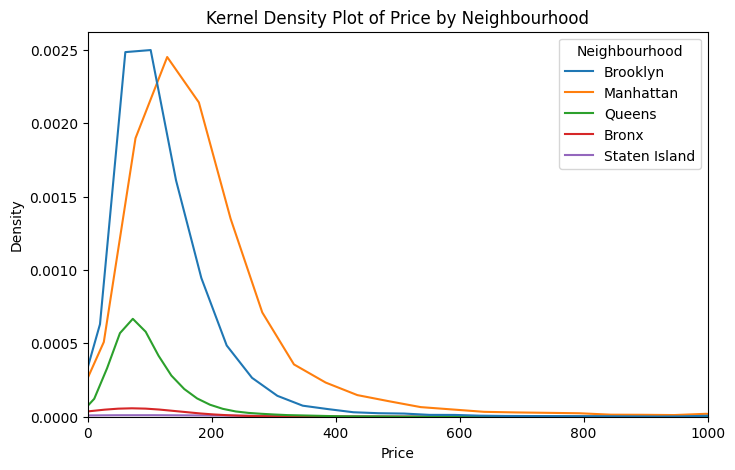

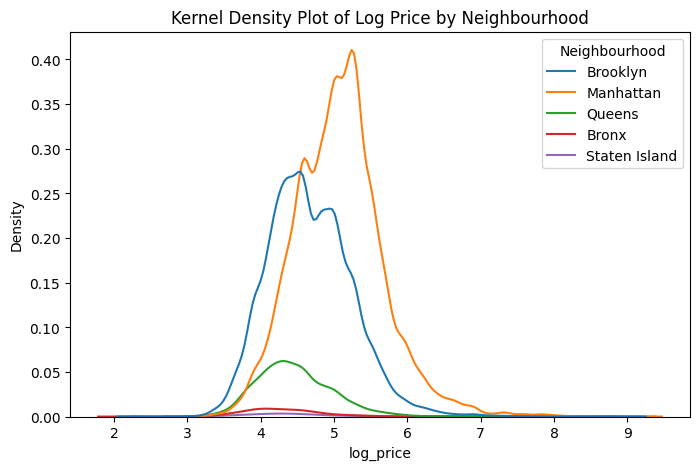

In [17]:
# Part 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data/airbnb_hw.csv')

# strip all hidden spaces from every column name, was causing error
df.columns = df.columns.str.strip()

# remove commas/dollar signs and force Price to be a number
df['Price'] = df['Price'].astype(str).str.replace(',', '').str.replace('$', '')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# compute average prices and scores by Neighbourhood
group_means = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean()
print("Group Means:\n", group_means)

# most expensive borough
most_expensive = group_means['Price'].idxmax()
print(f"\nThe most expensive borough on average is: {most_expensive}\n")

# log price column (dropping prices of 0 to avoid math errors)
df_plot = df[df['Price'] > 0].copy()
df_plot['log_price'] = np.log(df_plot['Price'])

# plotting Kernel Density for Price
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_plot, x='Price', hue='Neighbourhood')
plt.title('Kernel Density Plot of Price by Neighbourhood')
plt.xlim(0, 1000) # Zooming in to see the bulk of the data better
plt.show()

# plotting Kernel Density for Log Price
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_plot, x='log_price', hue='Neighbourhood')
plt.title('Kernel Density Plot of Log Price by Neighbourhood')
plt.show()

Can see from output that the most expensive borough on average is Manhattan.

In [18]:
# Part 2
from sklearn.linear_model import LinearRegression
import pandas as pd

# filter data to just the columns we need and drop any missing values
tdf = df[['Price', 'Neighbourhood']].dropna()
y = tdf['Price']

# create one-hot encoded dummy variables.
# drop_first=True exactly like the car color example in Notebook
X_hood = pd.get_dummies(tdf['Neighbourhood'], dtype='int', drop_first=True)

# fit the linear model
model = LinearRegression().fit(X_hood, y)

# print out the intercept and the coefficients
print(f'Model intercept: {model.intercept_}')
print("\nCoefficients:")
print(pd.DataFrame({'variable': model.feature_names_in_, 'coefficient': model.coef_}))

Model intercept: 94.66086956521724

Coefficients:
        variable  coefficient
0       Brooklyn    34.839602
1      Manhattan   103.813714
2         Queens     8.561255
3  Staten Island    68.801715


Because I used drop_first=True to avoid the dummy variable trap, the model dropped the "Bronx" category to use it as our baseline.

Because of this, the model intercept (94.66) is exactly equal to the conditional group mean (average price) of the Bronx from above.

The estimated coefficients represent the exact difference in average price between each specific neighborhood and the Bronx. For example, if you add the intercept and the Manhattan coefficient together (94.66 + 103.81), it will perfectly match the conditional average price of Manhattan from Part 1 which is pretty cool.

In [19]:
# Part 3
from sklearn.linear_model import LinearRegression

# filter data for just the two columns we need and drop missing values
tdf_review = df[['Price', 'Review Scores Rating']].dropna()
y_review = tdf_review['Price']

# scikit-learn expects X to be a 2D DataFrame, so we use double brackets
X_review = tdf_review[['Review Scores Rating']]

# fit the linear model
model_review = LinearRegression().fit(X_review, y_review)

print(f"Model intercept: {model_review.intercept_}")
print(f"Slope Coefficient for Review Scores Rating: {model_review.coef_[0]}")

Model intercept: 60.876922431700294
Slope Coefficient for Review Scores Rating: 1.02084371477775


The slope coefficient is approximately 1.02. This means that, on average, for every 1-point increase in a property's Review Scores Rating, the expected nightly price increases by about $1.02.

In [20]:
# Part 4
from sklearn.linear_model import LinearRegression
import pandas as pd

# filter data for our three columns / drop missing
tdf_combined = df[['Price', 'Review Scores Rating', 'Neighbourhood']].dropna()
y_combined = tdf_combined['Price']

# numeric and dummy variables, then combine them (drop_first=True for dummy)
X_num = tdf_combined[['Review Scores Rating']]
X_cat = pd.get_dummies(tdf_combined['Neighbourhood'], dtype='int', drop_first=True)
X_combined = pd.concat([X_num, X_cat], axis=1)

# multiple linear regression model
model_combined = LinearRegression().fit(X_combined, y_combined)

print(f'Model intercept: {model_combined.intercept_}')
print("\nCombined Model Coefficients:")
print(pd.DataFrame({'Variable': model_combined.feature_names_in_, 'Coefficient': model_combined.coef_}))

Model intercept: -23.80878603675302

Combined Model Coefficients:
               Variable  Coefficient
0  Review Scores Rating     1.081075
1              Brooklyn    51.704269
2             Manhattan   108.223983
3                Queens    21.694595
4         Staten Island    71.766519


With multiple regression, the slope for the Review Scores Rating increases slightly from roughly 1.02 to 1.08. This new slope means that within the exact same neighborhood, a 1-point increase in a review score is expected to raise the price by about $1.08.

Furthermore, the neighborhood averages (coefficients) all increased compared to Part 2. These new coefficients no longer represent raw price differences. They represent the expected price difference between each borough and the Bronx for properties that have the exact same review score, meaning we have successfully filtered out the overlapping influence of reviews.

In [21]:
# Part 5
from sklearn.linear_model import LinearRegression
import pandas as pd

# to get a slope for all neighborhoods, we get dummies without dropping the first one
X_all_hoods = pd.get_dummies(tdf_combined['Neighbourhood'], dtype='int', drop_first=False)

# create a new dataframe just for our interaction terms
X_puzzle = pd.DataFrame()

# multiply each neighborhood's 0/1 dummy by the Review Score Rating
for col in X_all_hoods.columns:
    X_puzzle[f'{col} * Review Score'] = X_all_hoods[col] * tdf_combined['Review Scores Rating']

# fit the model (the constant/intercept is included automatically)
model_puzzle = LinearRegression().fit(X_puzzle, y_combined)

print(f'Model intercept: {model_puzzle.intercept_}')
print("\nSeparate Slopes for Review Scores by Neighborhood:")
print(pd.DataFrame({'Variable': model_puzzle.feature_names_in_, 'Coefficient': model_puzzle.coef_}))

Model intercept: 55.12024139484684

Separate Slopes for Review Scores by Neighborhood:
                       Variable  Coefficient
0          Bronx * Review Score     0.222696
1       Brooklyn * Review Score     0.790926
2      Manhattan * Review Score     1.399302
3         Queens * Review Score     0.456430
4  Staten Island * Review Score     0.682422


The slopes are different across neighborhoods, proving that the financial reward for a higher review score depends heavily on location. Example: a 1-point increase in a review rating in Manhattan is associated with a price increase of about 1.40. However, that exact same 1-point increase in the Bronx only yields an extra 0.22. This tells us that customers booking in expensive, high-demand boroughs are willing to pay a much larger premium for highly-rated properties compared to customers booking in more budget-friendly boroughs.

This pattern makes sense because in a competitive, high-price market like Manhattan, a strong reputation is a genuine differentiator that commands a real price premium, whereas in lower-demand boroughs where price sensitivity is higher, customers are less willing to pay extra for a better rating.

In [22]:
# Part 6
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

# setup 10 folds using notebook
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

print("10-Fold Cross Validation Results:")

# part 3 model: just review scores
scores_3 = -cross_val_score(LinearRegression(), X_num, y_combined, cv=kfold, scoring='neg_mean_squared_error')
print(f"part 3 average MSE: {np.mean(scores_3):,.2f}")

# part 4 model: review Scores and neighborhood averages
scores_4 = -cross_val_score(LinearRegression(), X_combined, y_combined, cv=kfold, scoring='neg_mean_squared_error')
print(f"part 4 average MSE: {np.mean(scores_4):,.2f}")

# part 5 model: separate slopes (interaction terms)
scores_5 = -cross_val_score(LinearRegression(), X_puzzle, y_combined, cv=kfold, scoring='neg_mean_squared_error')
print(f"part 5 average MSE: {np.mean(scores_5):,.2f}")

10-Fold Cross Validation Results:
part 3 average MSE: 22,079.04
part 4 average MSE: 21,071.15
part 5 average MSE: 21,048.11


Based on the 10-fold cross-validation, the separate slopes (part 5) is the best performing model because it achieved the lowest average Mean Squared Error (21,048.11).

Adding the neighborhood averages (part 4) provided a massive improvement over using review scores alone (part 3). However, adding the interaction terms to give each neighborhood its own slope (part 5) improved the model even further. In the context of the bias-variance trade-off, the extra complexity of those separate slopes captured a real-world pattern in the data without crossing the line into overfitting.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


Overall Price Summary:
 count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

Grouped by Body_Type Summary:
            count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan    

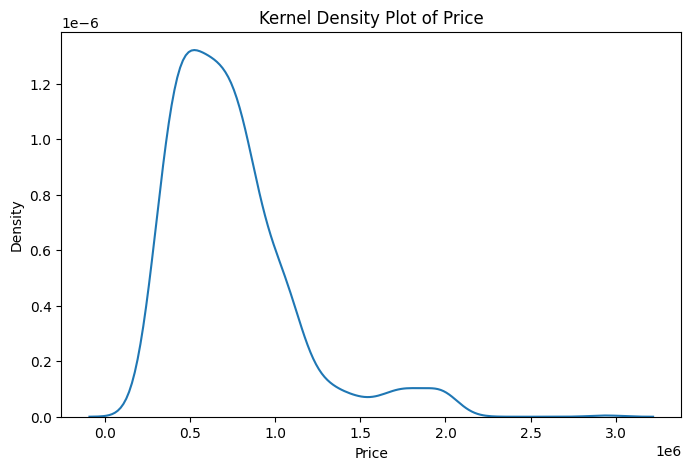

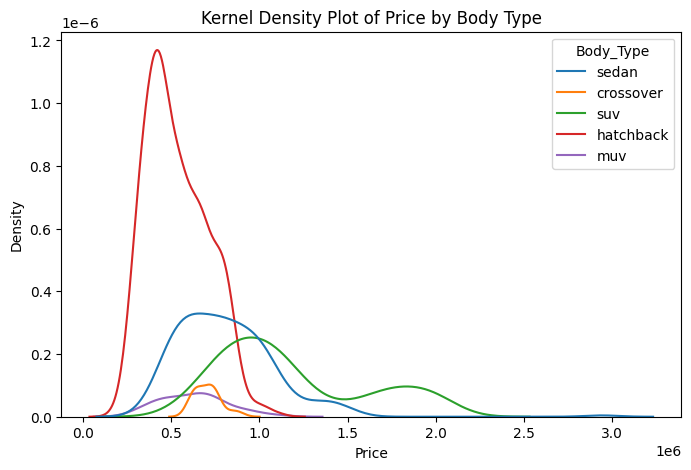

In [2]:
#part 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data/cars_hw.csv')

print("Overall Price Summary:\n", df['Price'].describe())

# group by Body_Type and describe
grouped_summary = df.groupby('Body_Type')['Price'].describe()
print("\nGrouped by Body_Type Summary:\n", grouped_summary)

# KDE for overall Price
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Price')
plt.title('Kernel Density Plot of Price')
plt.show()

# grouped KDE by Body_Type
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='Price', hue='Body_Type')
plt.title('Kernel Density Plot of Price by Body Type')
plt.show()

Based on the grouped kernel density plot, SUVs are the most expensive car type, as their distribution curve is shifted the furthest to the right along the price axis. SUVs also have the most variance, which is shown by their curve being the widest and flattest, spanning the largest overall range of prices compared to the tightly packed curves of types like hatchbacks.

In [3]:
#part 2
from sklearn.linear_model import LinearRegression
import pandas as pd

# filter out any missing values just in case
tdf = df[['Price', 'Seating_Capacity']].dropna()
y = tdf['Price']

# continuous regression (treating seats as a regular number)
X_num = tdf[['Seating_Capacity']]
model_num = LinearRegression().fit(X_num, y)
print(f"Slope coefficient (numeric): {model_num.coef_[0]}")

# categorical regression (treating seats as categories/dummy variables)
# .astype(str) here so scikit-learn keeps the feature_names_in_ attribute
X_cat = pd.get_dummies(tdf['Seating_Capacity'].astype(str), dtype='int', drop_first=True)
model_cat = LinearRegression().fit(X_cat, y)

print("\nCategorical Coefficients (vs Baseline):")
print(pd.DataFrame({'Seats': model_cat.feature_names_in_, 'Coefficient': model_cat.coef_}))

Slope coefficient (numeric): 59267.99803672175

Categorical Coefficients (vs Baseline):
  Seats   Coefficient
0     5  5.464839e+05
1     6  1.456000e+06
2     7  7.359487e+05
3     8  2.718000e+05


The numeric slope coefficient is roughly 59,268, meaning that for every one additional seat added to a car, the expected price increases by about 59,268 rupees. However, when treating seating capacity as categorical, we can clearly see the differences in price are not linear. Instead of increasing by a steady amount per seat, the price premiums jump around wildly, spiking highest for a 6-seater (+1.45 million) before actually dropping back down for 7- and 8-seaters.

In [4]:
#part 3
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np
import pandas as pd

# create Age variable
df['Age'] = np.max(df['Make_Year']) - df['Make_Year']
#filter
tdf_age = df[['Price', 'Age']].dropna()
y_age = tdf_age['Price']
X_base = tdf_age[['Age']].copy()

# create the 10 folds using the exact setup from notebook 06
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

# test powers 1, 2, 3, and 4
for power in range(1, 5):
    if power > 1:
        # add the new powered column
        X_base[f'Age^{power}'] = X_base['Age'] ** power

    model_poly = LinearRegression()

    # k-fold CV
    scores = -cross_val_score(model_poly, X_base, y_age, cv=kfold, scoring='neg_mean_squared_error')
    # scikit-learn requires 'neg_mean_squared_error' as the string name for the loss function,
    # so had to multiply by -1 to flip it back to a positive MSE
    print(f"Model up to Power {power} - Average MSE: {np.mean(scores):,.2f}")

Model up to Power 1 - Average MSE: 97,593,991,873.85
Model up to Power 2 - Average MSE: 97,788,769,710.30
Model up to Power 3 - Average MSE: 97,182,824,586.85
Model up to Power 4 - Average MSE: 96,657,152,963.87


The 10-fold cross-validation shows that the Power 4 model is the most effective because it produced the lowest average Mean Squared Error. This result indicates that the relationship between a car's age and its price is complex and non-linear. By adding higher-order polynomial terms, the model can accurately capture the vehicle's depreciation curve without overfitting the data.

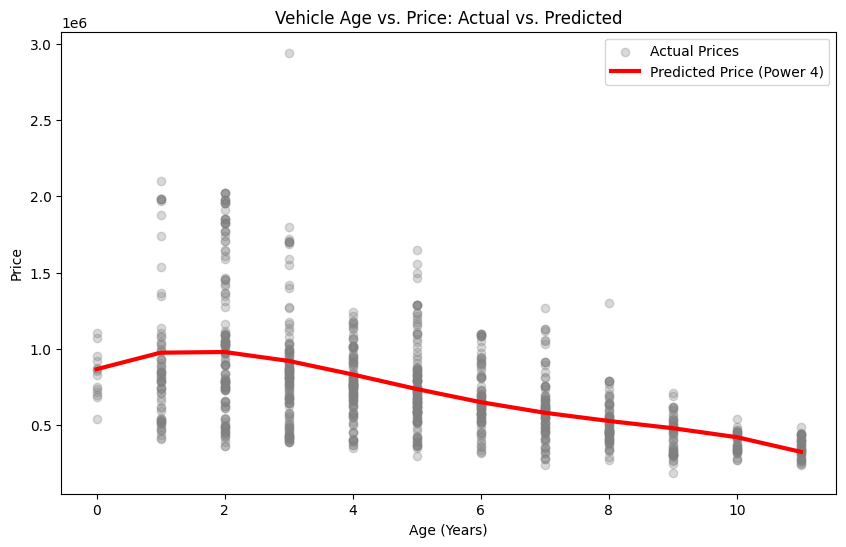

In [5]:
#part 4
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Based on part 3 results, power 4 best
X_final = tdf_age[['Age']].copy()
X_final['Age^2'] = X_final['Age'] ** 2
X_final['Age^3'] = X_final['Age'] ** 3
X_final['Age^4'] = X_final['Age'] ** 4

# fit the final model
model_final = LinearRegression().fit(X_final, y_age)

# generate predictions
y_hat = model_final.predict(X_final)

# plot a smooth line, we must sort the data by Age
sort_idx = np.argsort(tdf_age['Age'])
age_sorted = tdf_age['Age'].iloc[sort_idx]
y_hat_sorted = y_hat[sort_idx]

# plotting
plt.figure(figsize=(10, 6))
plt.scatter(tdf_age['Age'], y_age, alpha=0.3, label='Actual Prices', color='gray')
plt.plot(age_sorted, y_hat_sorted, color='red', linewidth=3, label='Predicted Price (Power 4)')

plt.xlabel("Age (Years)")
plt.ylabel("Price")
plt.title("Vehicle Age vs. Price: Actual vs. Predicted")
plt.legend()
plt.show()

The model accurately captures the general downward trend of vehicle prices as they age, successfully fitting a non-linear curve that follows the "bulk" of the data points. While it cannot predict the specific price of every individual car due to the high amount of vertical spread (variance), it effectively represents the average market value across different ages.


**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables: (Downloaded this from the email)

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [23]:
# Part 1
import pandas as pd

df_heart = pd.read_csv('/content/heart_hw.csv')

# 'y' is coded as 1 (survival) and 0 (death)
# calculating the mean automatically gives us the proportion of people who survived
survival_rates = df_heart.groupby('transplant')['y'].mean()

# specific proportions
prop_control = survival_rates['control']
prop_treatment = survival_rates['treatment']

# Average Treatment Effect (ATE)
ate = prop_treatment - prop_control

print(f"(a) Survival proportion (Control): {prop_control:.4f}")
print(f"(b) Survival proportion (Treatment): {prop_treatment:.4f}")
print(f"Average Treatment Effect (ATE): {ate:.4f}")

(a) Survival proportion (Control): 0.1176
(b) Survival proportion (Treatment): 0.3478
Average Treatment Effect (ATE): 0.2302


Average Treatment Effect (ATE): The ATE on three-year survival for heart transplant interventions is 0.2302. This means that, in this dataset, receiving a heart transplant increases the average probability of surviving for three years by roughly 23 percentage points compared to not receiving one.

In [24]:
# Part 2
from sklearn.linear_model import LinearRegression

# create a 1/0 dummy variable. 1 if treatment, 0 if control
df_heart['treatment_dummy'] = (df_heart['transplant'] == 'treatment').astype(int)

# X and y
X_transplant = df_heart[['treatment_dummy']]
y_heart = df_heart['y']

# linear model
model_simple = LinearRegression().fit(X_transplant, y_heart)

print(f"Model Intercept: {model_simple.intercept_:.4f}")
print(f"Transplant Coefficient: {model_simple.coef_[0]:.4f}")

Model Intercept: 0.1176
Transplant Coefficient: 0.2302


Numbers confirm that a simple linear regression on a dummy variable is mathematically identical to calculating the difference in group averages. (same as part 1 numbers)

Part 3 Regression Results:
Intercept: 0.7020
Transplant Coefficient: 0.2647
Age Coefficient: -0.0136


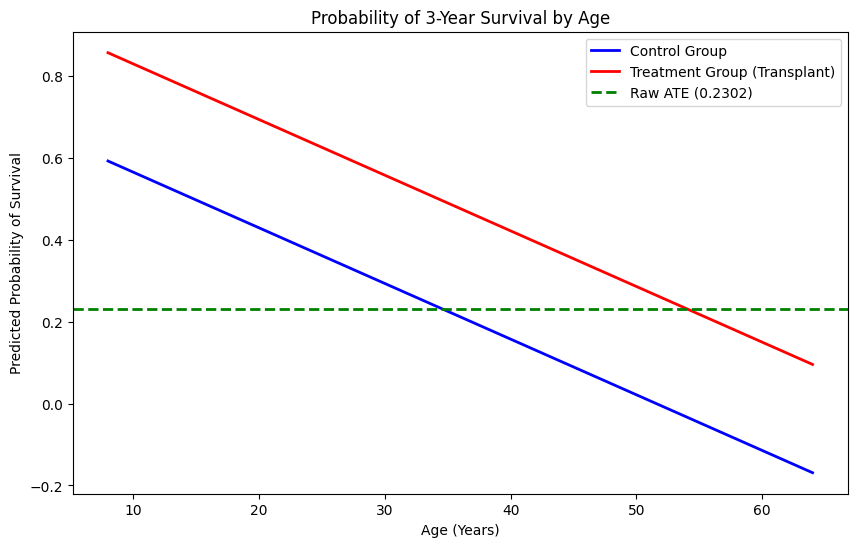

In [26]:
# Part 3
import matplotlib.pyplot as plt
import numpy as np

# already have 'treatment_dummy' from Part 2
X_age_trans = df_heart[['treatment_dummy', 'age']]
y_heart = df_heart['y']

# multiple linear regression model
model_part3 = LinearRegression().fit(X_age_trans, y_heart)

print("Part 3 Regression Results:")
print(f"Intercept: {model_part3.intercept_:.4f}")
print(f"Transplant Coefficient: {model_part3.coef_[0]:.4f}")
print(f"Age Coefficient: {model_part3.coef_[1]:.4f}")

# plot
plt.figure(figsize=(10, 6))

# range of ages based on the dataset to draw smooth lines
ages = np.linspace(df_heart['age'].min(), df_heart['age'].max(), 100)

# calculate predicted probabilities using our model's coefficients
# control line equation (treatment_dummy = 0)
pred_control = model_part3.intercept_ + (model_part3.coef_[1] * ages)
# treatment line equation (treatment_dummy = 1)
pred_treatment = model_part3.intercept_ + model_part3.coef_[0] + (model_part3.coef_[1] * ages)

# plot the regression lines
plt.plot(ages, pred_control, label='Control Group', color='blue', linewidth=2)
plt.plot(ages, pred_treatment, label='Treatment Group (Transplant)', color='red', linewidth=2)

# raw ATE from Part 1 (0.2302)
plt.axhline(y=0.2302, color='green', linestyle='--', linewidth=2, label='Raw ATE (0.2302)')

plt.xlabel("Age (Years)")
plt.ylabel("Predicted Probability of Survival")
plt.title("Probability of 3-Year Survival by Age")
plt.legend()
plt.show()

Controlling for age increases the transplant coefficient from 0.2302 to 0.2647. This shows that the raw ATE underestimated the treatment's effectiveness because age was acting as a confounding variable.

The intercept (0.7020) is the baseline survival probability for a hypothetical 0 year old control patient, while the transplant slope (0.2647) is the isolated survival boost given to a patient of the exact same age. The age slope (-0.0136) indicates that a patient's survival probability drops by about 1.36% for every additional year of life.

Based on the graph, the static raw ATE underestimates the baseline survival chances for younger patients (under roughly 35 years old). Conversely, it overestimates the survival probability for older patients (over roughly 54 years old), whose chances drop below the 23% mark even with a transplant.

Part 4 Regression Results:
Intercept: 0.3549
Transplant Coefficient: 0.9078
Age Coefficient: -0.0055
Interaction (Transplant * Age) Coefficient: -0.0146


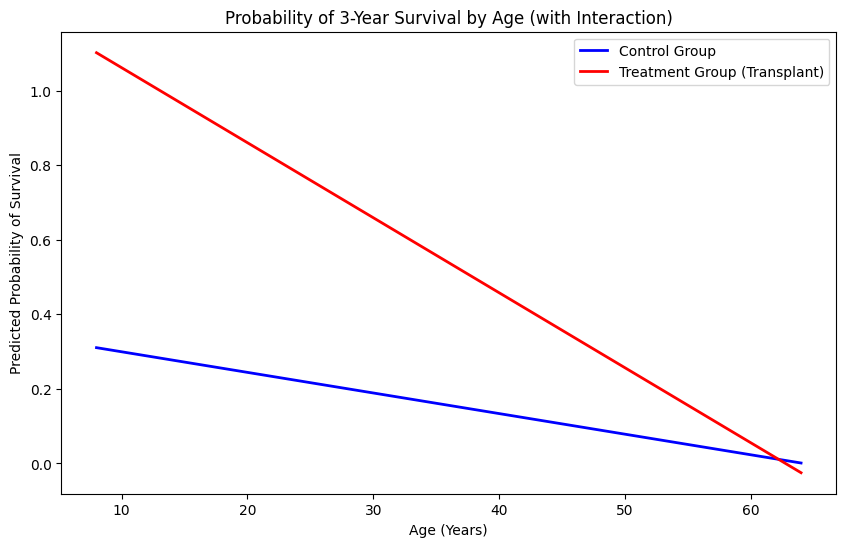

In [27]:
# Part 4
# interaction term: Multiply the dummy (1 or 0) by the patient's age
df_heart['transplant_x_age'] = df_heart['treatment_dummy'] * df_heart['age']

# three variables
X_interaction = df_heart[['treatment_dummy', 'age', 'transplant_x_age']]
y_heart = df_heart['y']

# fit
model_part4 = LinearRegression().fit(X_interaction, y_heart)

print("Part 4 Regression Results:")
print(f"Intercept: {model_part4.intercept_:.4f}")
print(f"Transplant Coefficient: {model_part4.coef_[0]:.4f}")
print(f"Age Coefficient: {model_part4.coef_[1]:.4f}")
print(f"Interaction (Transplant * Age) Coefficient: {model_part4.coef_[2]:.4f}")

# plot
plt.figure(figsize=(10, 6))
ages = np.linspace(df_heart['age'].min(), df_heart['age'].max(), 100)

# calculate predicted probabilities.
# control line: treatment_dummy = 0, transplant_x_age = 0
pred_control = model_part4.intercept_ + (model_part4.coef_[1] * ages)

# treatment line: treatment_dummy = 1, transplant_x_age = ages
pred_treatment = model_part4.intercept_ + model_part4.coef_[0] + (model_part4.coef_[1] * ages) + (model_part4.coef_[2] * ages)

plt.plot(ages, pred_control, label='Control Group', color='blue', linewidth=2)
plt.plot(ages, pred_treatment, label='Treatment Group (Transplant)', color='red', linewidth=2)

plt.xlabel("Age (Years)")
plt.ylabel("Predicted Probability of Survival")
plt.title("Probability of 3-Year Survival by Age (with Interaction)")
plt.legend()
plt.show()

Allowing the variables to interact removes the assumption of a constant, parallel survival benefit for all patients. Instead, the predictions now show that the survival boost provided by the transplant depends entirely on the specific age of the patient.

The graph shows the treatment and control lines converging and eventually crossing, which is driven by the negative interaction coefficient (-0.0146). This pattern shows that the survival benefit of a heart transplant is massive for younger patients, but steadily decreases as patients age, eventually offering no benefit to the oldest patients in the dataset.

Unlike the parallel-line model in Part 3, the raw ATE of 0.2302 now only accurately reflects the treatment effect at one specific age, roughly the middle of the sample. For younger patients, the flat ATE line significantly underestimates the transplant's benefit, since the interaction model predicts a much larger survival boost at lower ages. For older patients near the crossover point of the two lines, the ATE substantially overestimates the benefit, eventually describing a positive effect where the model predicts the transplant provides little to no survival advantage at all.

In [28]:
# Part 5
from sklearn.model_selection import KFold, cross_val_score

# 10-fold cross validation
kfold = KFold(n_splits=10, shuffle=True, random_state=100)

# fresh linear regression model
model_cv = LinearRegression()

# part 2 model (Transplant Only)
scores_part2 = -cross_val_score(model_cv, X_transplant, y_heart, cv=kfold, scoring='neg_mean_squared_error')

# part 3 model (Transplant + Age)
scores_part3 = -cross_val_score(model_cv, X_age_trans, y_heart, cv=kfold, scoring='neg_mean_squared_error')

# part 4 model (Transplant, Age, and Interaction)
scores_part4 = -cross_val_score(model_cv, X_interaction, y_heart, cv=kfold, scoring='neg_mean_squared_error')

print("--- 10-Fold Cross Validation Results (Average MSE) ---")
print(f"Part 2 Model (Transplant Only): {np.mean(scores_part2):.4f}")
print(f"Part 3 Model (Transplant + Age): {np.mean(scores_part3):.4f}")
print(f"Part 4 Model (Interaction Term): {np.mean(scores_part4):.4f}")

--- 10-Fold Cross Validation Results (Average MSE) ---
Part 2 Model (Transplant Only): 0.1937
Part 3 Model (Transplant + Age): 0.1817
Part 4 Model (Interaction Term): 0.1807


Based on the 10-fold cross-validation, the Part 4 Model (Interaction Term) is the most predictively accurate because it achieved the lowest average Mean Squared Error (0.1807). This confirms that allowing the impact of a transplant to vary by age captures a real-world pattern that improves survival predictions more effectively than the simpler models.

**PART 6:**
One big worry about using this model to decide who gets a transplant is that it basically turns into "age discrimination." Because our model shows that survival chances drop as people get older, the algorithm would automatically push older patients to the back of the line, even if they are otherwise healthy. It’s a very "cold" way to make a decision because it only looks at survival probability and ignores the actual human being or their quality of life.

Also, from a data standpoint, this model is way too simple to be making life-or-death calls. We are only looking at age and whether they got the transplant, but we are missing a ton of other important stuff (like a patient's overall health history, their lifestyle, or even where they live). Plus, since we're using a basic linear model for a "yes or no" outcome (survival), the model can sometimes spit out impossible predictions, like a survival chance higher than 100% or lower than 0%, which shows it’s not a perfect tool for this kind of high stakes deployment.